In [23]:
# ==========================================
# CELL 1: Import Libraries & Core Functions
# ==========================================
import cv2
import rawpy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew
from sklearn.preprocessing import PolynomialFeatures

import sys

# Mendaftarkan jalur utama proyek ke dalam path Python
JALUR_UTAMA = r'C:\Folder Dzakwan\Folder Dzakwan\Keperluan TA'
if JALUR_UTAMA not in sys.path:
    sys.path.append(JALUR_UTAMA)

# Setelah path didaftarkan, modul bisa di-import
try:
    from scripts.ColorCorrectionML import ColorCorrectionML
    print("Modul ColorCorrectionML berhasil di-import!")
except ImportError:
    print(f"Error: Modul ColorCorrectionML tetap tidak ditemukan di {JALUR_UTAMA}")

def ambil_gambar_raw(dng_path):
    with rawpy.imread(dng_path) as raw:
        rgb_image = raw.postprocess(use_camera_wb=True, exp_shift=1.0)
    return rgb_image

def roi_cropping(image_rgb, mask):
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not contours:
        return image_rgb, mask
    
    c = max(contours, key=cv2.contourArea)
    x, y, w, h = cv2.boundingRect(c)
    
    padding = 10
    x1 = max(0, x - padding)
    y1 = max(0, y - padding)
    x2 = min(image_rgb.shape[1], x + w + padding)
    y2 = min(image_rgb.shape[0], y + h + padding)
    
    cropped_img = image_rgb[y1:y2, x1:x2]
    cropped_mask = mask[y1:y2, x1:x2]
    return cropped_img, cropped_mask

def restoration(image_rgb, mask):
    gray = cv2.cvtColor(image_rgb, cv2.COLOR_RGB2GRAY)
    _, bright_mask = cv2.threshold(gray, 240, 255, cv2.THRESH_BINARY)
    bright_mask_in_eye = cv2.bitwise_and(bright_mask, mask)
    
    img_bgr = cv2.cvtColor(image_rgb, cv2.COLOR_RGB2BGR)
    inpainted_bgr = cv2.inpaint(img_bgr, bright_mask_in_eye, inpaintRadius=8, flags=cv2.INPAINT_NS)
    inpainted_rgb = cv2.cvtColor(inpainted_bgr, cv2.COLOR_BGR2RGB)
    return inpainted_rgb, bright_mask_in_eye

def color_correction(target_img, cc_img):
    bgr_cc = cv2.cvtColor(cc_img, cv2.COLOR_RGB2BGR)
    cc_ml = ColorCorrectionML(bgr_cc, chart='Classic', illuminant='D50')
    src_awal, _, _ = cc_ml.extract_color_chart()

    degree = 3
    model_pls, _ = cc_ml.compute_correction(show=False, method='pls', degree=degree, interactions_only=False, ncomp=10)
    poly = PolynomialFeatures(degree=degree, interaction_only=False)
    
    img = target_img.copy() 
    h, w, c = img.shape
    img_flat = img.reshape(-1, 3)

    poly.fit(img_flat[:1])
    img_corrected_flat = np.zeros_like(img_flat, dtype=np.float32)
    chunk_size = 1_000_000

    for i in range(0, len(img_flat), chunk_size):
        chunk = img_flat[i:i+chunk_size].astype(np.float32)
        chunk_poly = poly.transform(chunk)
        img_corrected_flat[i:i+chunk_size] = model_pls.predict(chunk_poly)

    corrected_img = np.clip(img_corrected_flat, 0, 255).astype(np.uint8).reshape(h, w, c)

    return corrected_img

def extract_hue_pixels(image_rgb, mask):
    """
    Ekstrak piksel channel Hue (H) dari HSV untuk visualisasi distribusi antar HP.
    """
    hsv_image = cv2.cvtColor(image_rgb, cv2.COLOR_RGB2HSV)
    h_channel = hsv_image[:, :, 0] # Di OpenCV, H memiliki rentang 0-179
    valid_pixels = mask == 255
    
    return h_channel[valid_pixels]

def calculate_hhr(hue_pixels, threshold_low=15, threshold_high=160):
    """
    Kalkulasi nilai skalar HHR (High Hue Rate).
    Mengukur persentase piksel konjungtiva yang berada di spektrum kemerahan.
    
    Catatan: Anda dapat menyesuaikan threshold_low dan threshold_high
    berdasarkan rumusan referensi penelitian HHR yang Anda gunakan.
    """
    if len(hue_pixels) == 0:
        return 0.0
        
    # Masking piksel yang tergolong "High Hue" (Area kemerahan)
    high_hue_condition = ((hue_pixels >= 0) & (hue_pixels <= threshold_low)) | (hue_pixels >= threshold_high)
    
    # Hitung rasionya
    hhr_value = np.sum(high_hue_condition) / len(hue_pixels)
    
    return hhr_value

Modul ColorCorrectionML berhasil di-import!


In [24]:
# ==========================================
# CELL 2: Feature Extraction Functions
# ==========================================
def extract_a_star_pixels(image_rgb, mask):
    """
    Ekstrak array 1D piksel a* untuk kebutuhan visualisasi distribusi konsistensi.
    """
    valid_pixels = mask == 255
    lab_image = cv2.cvtColor(image_rgb, cv2.COLOR_RGB2LAB)
    _, a, _ = cv2.split(lab_image)
    
    return a[valid_pixels]

def extract_features(image_rgb, mask):
    """
    Ekstrak 27 fitur statistik (Mean, Std, Skew) untuk semua channel warna.
    Digunakan untuk data primer di model regresi (Ablation Validation).
    """
    features = {}
    valid_pixels = mask == 255
    channels = {}
    
    r, g, b = cv2.split(image_rgb)
    channels.update({'R': r, 'G': g, 'B': b})
    
    hsv_image = cv2.cvtColor(image_rgb, cv2.COLOR_RGB2HSV)
    h, s, v = cv2.split(hsv_image)
    channels.update({'H': h, 'S': s, 'V': v})
    
    lab_image = cv2.cvtColor(image_rgb, cv2.COLOR_RGB2LAB)
    l, a, b_lab = cv2.split(lab_image)
    channels.update({'L': l, 'A': a, 'B_lab': b_lab})
    
    for channel_name, channel_data in channels.items():
        pixel_values = channel_data[valid_pixels]
        if len(pixel_values) > 0:
            features[f'{channel_name}_Mean'] = np.mean(pixel_values)
            features[f'{channel_name}_Std'] = np.std(pixel_values)
            
    return features

In [25]:
# ==========================================
# CELL 3: Run Pipeline & Extract Features
# ==========================================
def process_pipeline_for_consistency(dng_path, cc_path, mask_path):
    # 1. Ambil Gambar
    img_ori = ambil_gambar_raw(dng_path)
    cc_ori = ambil_gambar_raw(cc_path)
    
    # Load Mask
    mask_ori = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
    _, mask_ori = cv2.threshold(mask_ori, 127, 255, cv2.THRESH_BINARY)
    if mask_ori.shape != img_ori.shape[:2]:
        mask_ori = cv2.resize(mask_ori, (img_ori.shape[1], img_ori.shape[0]), interpolation=cv2.INTER_NEAREST)

    # 2. ROI Cropping
    roi_img, roi_mask = roi_cropping(img_ori, mask_ori)

    # 3. Restoration (Brightspot Denoising)
    restored_img, _ = restoration(roi_img, roi_mask)

    # 4. Color Correction
    corrected_img = color_correction(restored_img, cc_ori)
    
    # 5. Ekstraksi fitur SEBELUM dan SESUDAH koreksi
    a_star_raw = extract_a_star_pixels(restored_img, roi_mask)
    a_star_cc = extract_a_star_pixels(corrected_img, roi_mask)
    
    feat_raw = extract_features(restored_img, roi_mask)
    feat_cc = extract_features(corrected_img, roi_mask)
    
    return a_star_raw, a_star_cc, feat_raw, feat_cc

# Ganti dengan path .dng dan .png Anda yang sebenarnya
PATH_HP1_DNG = r'C:\Folder Dzakwan\Folder Dzakwan\Keperluan TA\dataset\Hasil Pengambilan Data\Hasil Gambar\Subj_11\iPhone 11\right.dng'
PATH_HP1_CC  = r'C:\Folder Dzakwan\Folder Dzakwan\Keperluan TA\dataset\Hasil Pengambilan Data\Hasil Gambar\Subj_11\iPhone 11\cc.dng'
PATH_HP1_MASK = r'C:\Folder Dzakwan\Folder Dzakwan\Keperluan TA\dataset\Hasil Pengambilan Data\Ground Truth\Subj_11\iPhone 11\right.png'

PATH_HP2_DNG = r'C:\Folder Dzakwan\Folder Dzakwan\Keperluan TA\dataset\Hasil Pengambilan Data\Hasil Gambar\Subj_11\Samsung A52s\right.dng'
PATH_HP2_CC  = r'C:\Folder Dzakwan\Folder Dzakwan\Keperluan TA\dataset\Hasil Pengambilan Data\Hasil Gambar\Subj_11\Samsung A52s\cc.dng'
PATH_HP2_MASK = r'C:\Folder Dzakwan\Folder Dzakwan\Keperluan TA\dataset\Hasil Pengambilan Data\Ground Truth\Subj_11\Samsung A52s\right.png'

print("Memproses HP 1...")
a_star_hp1_raw, a_star_hp1_cc, feat_hp1_raw, feat_hp1_cc = process_pipeline_for_consistency(PATH_HP1_DNG, PATH_HP1_CC, PATH_HP1_MASK)

print("Memproses HP 2...")
a_star_hp2_raw, a_star_hp2_cc, feat_hp2_raw, feat_hp2_cc = process_pipeline_for_consistency(PATH_HP2_DNG, PATH_HP2_CC, PATH_HP2_MASK)

print("Ekstraksi selesai.")

Memproses HP 1...
Initial mean DeltaE:  5.27268032238
Number of components:  10
Memproses HP 2...
Initial mean DeltaE:  8.20507121924
Number of components:  10
Ekstraksi selesai.


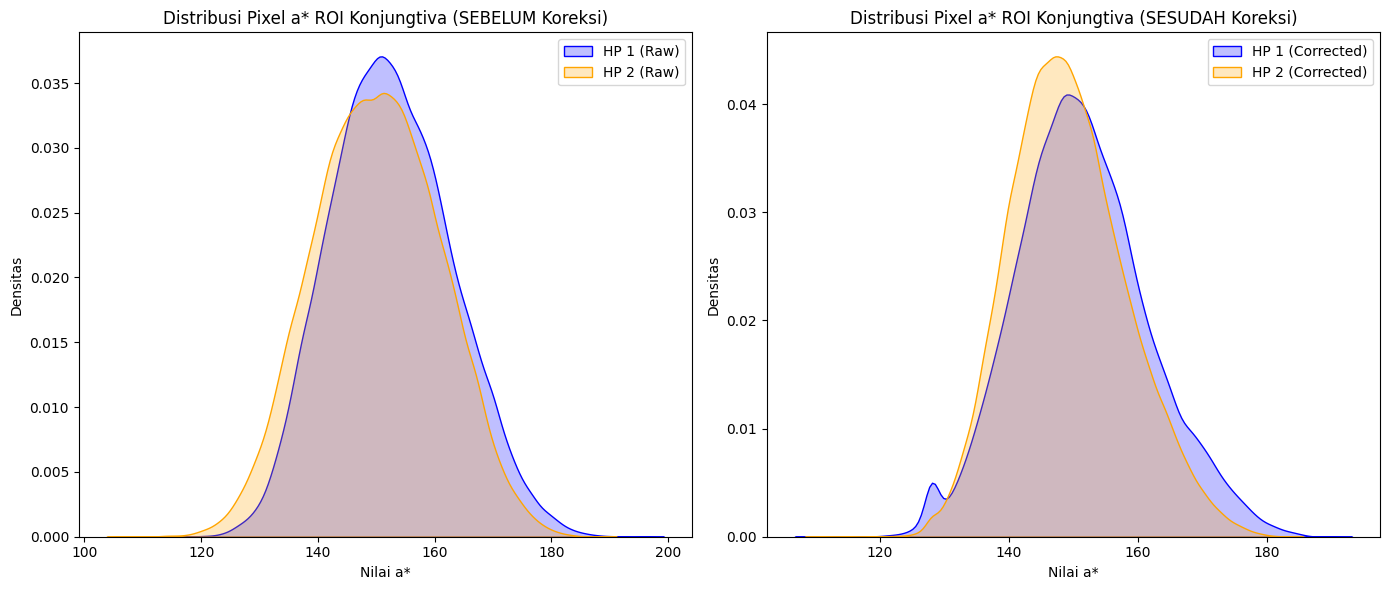

Selisih rata-rata a* (A_Mean) sebelum koreksi : 2.460
Selisih rata-rata a* (A_Mean) sesudah koreksi : 2.094


In [26]:
# ==========================================
# CELL 4: Plotting Consistency Distribution
# ==========================================
plt.figure(figsize=(14, 6))

# Plot Sebelum Color Correction (Pada Restored Image)
plt.subplot(1, 2, 1)
sns.kdeplot(a_star_hp1_raw, fill=True, label="HP 1 (Raw)", color="blue")
sns.kdeplot(a_star_hp2_raw, fill=True, label="HP 2 (Raw)", color="orange")
plt.title("Distribusi Pixel a* ROI Konjungtiva (SEBELUM Koreksi)")
plt.xlabel("Nilai a*")
plt.ylabel("Densitas")
plt.legend()

# Plot Sesudah Color Correction
plt.subplot(1, 2, 2)
sns.kdeplot(a_star_hp1_cc, fill=True, label="HP 1 (Corrected)", color="blue")
sns.kdeplot(a_star_hp2_cc, fill=True, label="HP 2 (Corrected)", color="orange")
plt.title("Distribusi Pixel a* ROI Konjungtiva (SESUDAH Koreksi)")
plt.xlabel("Nilai a*")
plt.ylabel("Densitas")
plt.legend()

plt.tight_layout()
plt.show()

# Hitung selisih rata-rata a* antar HP
mean_hp1_raw, mean_hp2_raw = feat_hp1_raw['A_Mean'], feat_hp2_raw['A_Mean']
mean_hp1_cc, mean_hp2_cc = feat_hp1_cc['A_Mean'], feat_hp2_cc['A_Mean']

print(f"Selisih rata-rata a* (A_Mean) sebelum koreksi : {abs(mean_hp1_raw - mean_hp2_raw):.3f}")
print(f"Selisih rata-rata a* (A_Mean) sesudah koreksi : {abs(mean_hp1_cc - mean_hp2_cc):.3f}")

In [27]:
# ==========================================
# CELL 2: Run Pipeline & Hitung HHR
# ==========================================
def process_hhr_pipeline(dng_path, cc_path, mask_path):
    # 1. Ambil Gambar
    img_ori = ambil_gambar_raw(dng_path)
    cc_ori = ambil_gambar_raw(cc_path)
    
    # Load Mask
    mask_ori = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
    _, mask_ori = cv2.threshold(mask_ori, 127, 255, cv2.THRESH_BINARY)
    if mask_ori.shape != img_ori.shape[:2]:
        mask_ori = cv2.resize(mask_ori, (img_ori.shape[1], img_ori.shape[0]), interpolation=cv2.INTER_NEAREST)

    # 2. Eksekusi alur preprocessing
    roi_img, roi_mask = roi_cropping(img_ori, mask_ori)
    restored_img, _ = restoration(roi_img, roi_mask)
    corrected_img = color_correction(restored_img, cc_ori)
    
    # 3. Ekstraksi Distribusi Hue & Nilai HHR
    hue_raw = extract_hue_pixels(restored_img, roi_mask)
    hue_cc = extract_hue_pixels(corrected_img, roi_mask)
    
    hhr_raw = calculate_hhr(hue_raw)
    hhr_cc = calculate_hhr(hue_cc)
    
    return hue_raw, hue_cc, hhr_raw, hhr_cc

# Ganti variabel path ini ke file .dng Anda
print("Memproses HP 1...")
hue_hp1_raw, hue_hp1_cc, hhr_hp1_raw, hhr_hp1_cc = process_hhr_pipeline(PATH_HP1_DNG, PATH_HP1_CC, PATH_HP1_MASK)

print("Memproses HP 2...")
hue_hp2_raw, hue_hp2_cc, hhr_hp2_raw, hhr_hp2_cc = process_hhr_pipeline(PATH_HP2_DNG, PATH_HP2_CC, PATH_HP2_MASK)

print("Ekstraksi HHR selesai.")

Memproses HP 1...
Initial mean DeltaE:  5.27268032238
Number of components:  10
Memproses HP 2...
Initial mean DeltaE:  8.20507121924
Number of components:  10
Ekstraksi HHR selesai.


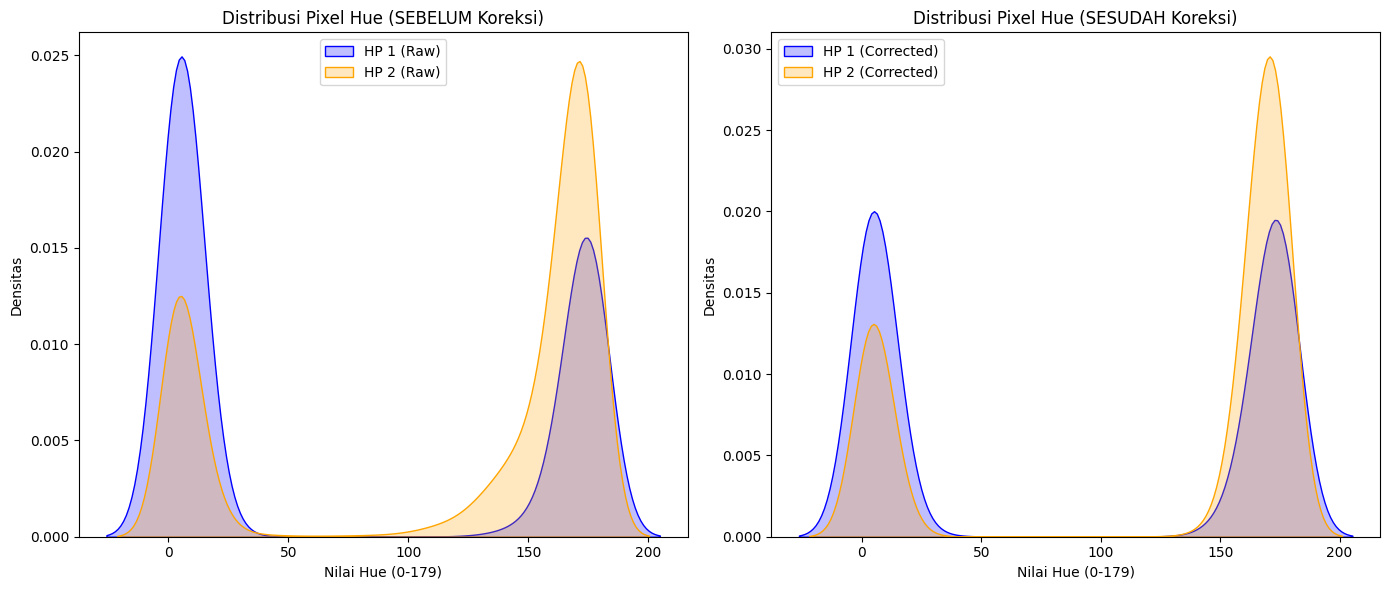

=== KONSISTENSI FITUR HHR (High Hue Rate) ===
HHR HP 1 (Raw)          : 0.9602
HHR HP 2 (Raw)          : 0.7988
Selisih Sebelum Koreksi : 0.1614
---------------------------------------------
HHR HP 1 (Corrected)    : 0.9613
HHR HP 2 (Corrected)    : 0.9363
Selisih Sesudah Koreksi : 0.0250


In [28]:
# ==========================================
# CELL 3: Plotting Konsistensi Hue & Evaluasi HHR
# ==========================================
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14, 6))

# Plot Sebelum CC
plt.subplot(1, 2, 1)
sns.kdeplot(hue_hp1_raw, fill=True, label="HP 1 (Raw)", color="blue")
sns.kdeplot(hue_hp2_raw, fill=True, label="HP 2 (Raw)", color="orange")
plt.title("Distribusi Pixel Hue (SEBELUM Koreksi)")
plt.xlabel("Nilai Hue (0-179)")
plt.ylabel("Densitas")
plt.legend()

# Plot Sesudah CC
plt.subplot(1, 2, 2)
sns.kdeplot(hue_hp1_cc, fill=True, label="HP 1 (Corrected)", color="blue")
sns.kdeplot(hue_hp2_cc, fill=True, label="HP 2 (Corrected)", color="orange")
plt.title("Distribusi Pixel Hue (SESUDAH Koreksi)")
plt.xlabel("Nilai Hue (0-179)")
plt.ylabel("Densitas")
plt.legend()

plt.tight_layout()
plt.show()

# Evaluasi Konsistensi Nilai Skalar HHR
print("=== KONSISTENSI FITUR HHR (High Hue Rate) ===")
print(f"HHR HP 1 (Raw)          : {hhr_hp1_raw:.4f}")
print(f"HHR HP 2 (Raw)          : {hhr_hp2_raw:.4f}")
print(f"Selisih Sebelum Koreksi : {abs(hhr_hp1_raw - hhr_hp2_raw):.4f}")
print("-" * 45)
print(f"HHR HP 1 (Corrected)    : {hhr_hp1_cc:.4f}")
print(f"HHR HP 2 (Corrected)    : {hhr_hp2_cc:.4f}")
print(f"Selisih Sesudah Koreksi : {abs(hhr_hp1_cc - hhr_hp2_cc):.4f}")

In [29]:
# ==========================================
# CELL: Ablation Validation on-the-fly (14 Features RF)
# ==========================================
import cv2
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import skew
from sklearn.metrics import r2_score, mean_squared_error

# Pastikan fungsi ambil_gambar_raw, roi_cropping, restoration, 
# dan color_correction sudah dijalankan (di-run) dari sel sebelumnya.

def extract_14_rf_features(image_rgb, mask, gender_encoded):
    """
    Mengekstrak tepat 14 fitur sesuai urutan training Random Forest:
    1. A_Mean 2. H_Skew 3. H_Std 4. B_lab_Std 5. Erythema_Index 
    6. High_Hue_Ratio 7. S_Mean 8. A_Std 9. B_lab_Mean 10. S_Std 
    11. R_Mean 12. Gender_Encoded 13. B_Mean 14. Red_Ratio
    """
    features = {}
    valid_pixels = mask == 255
    
    # 1. Ekstrak Channel Warna
    r, g, b = cv2.split(image_rgb)
    
    hsv_image = cv2.cvtColor(image_rgb, cv2.COLOR_RGB2HSV)
    h, s, v = cv2.split(hsv_image)
    
    lab_image = cv2.cvtColor(image_rgb, cv2.COLOR_RGB2LAB)
    l, a, b_lab = cv2.split(lab_image)
    
    # Filter hanya piksel di dalam ROI Konjungtiva (dikonversi ke float untuk akurasi rumus)
    r_val = r[valid_pixels].astype(np.float32)
    g_val = g[valid_pixels].astype(np.float32)
    b_val = b[valid_pixels].astype(np.float32)
    
    h_val = h[valid_pixels].astype(np.float32)
    s_val = s[valid_pixels].astype(np.float32)
    
    a_val = a[valid_pixels].astype(np.float32)
    b_lab_val = b_lab[valid_pixels].astype(np.float32)
    
    # --- KALKULASI FITUR ---
    
    # Fitur Statistik Dasar
    features['A_Mean'] = np.mean(a_val)
    features['H_Skew'] = skew(h_val) if len(h_val) > 2 else 0
    features['H_Std'] = np.std(h_val)
    features['B_lab_Std'] = np.std(b_lab_val)
    features['S_Mean'] = np.mean(s_val)
    features['A_Std'] = np.std(a_val)
    features['B_lab_Mean'] = np.mean(b_lab_val)
    features['S_Std'] = np.std(s_val)
    features['R_Mean'] = np.mean(r_val)
    features['B_Mean'] = np.mean(b_val)
    
    # Erythema Index (Formula umum: log10(R) - log10(G))
    # Epsilon (1e-5) ditambahkan untuk mencegah error log(0)
    epsilon = 1e-5
    ei_values = np.log10(r_val + epsilon) - np.log10(g_val + epsilon)
    features['Erythema_Index'] = np.mean(ei_values)
    
    # Red Ratio (Formula: R / (R + G + B))
    sum_rgb = r_val + g_val + b_val + epsilon
    red_ratio_values = r_val / sum_rgb
    features['Red_Ratio'] = np.mean(red_ratio_values)
    
    # High Hue Ratio (Asumsi spektrum kemerahan di OpenCV: 0-15 dan 160-179)
    high_hue_condition = ((h_val >= 0) & (h_val <= 15)) | (h_val >= 160)
    features['High_Hue_Ratio'] = np.sum(high_hue_condition) / len(h_val) if len(h_val) > 0 else 0
    
    # Fitur Metadata
    features['Gender_Encoded'] = gender_encoded
    
    return features

In [30]:
import os
import pandas as pd

# 1. PERSIAPAN DATA UJI (MENGGUNAKAN SELURUH DATA PRIMER)
# Path menuju dataset Excel yang baru
path_metadata = r'C:\Folder Dzakwan\Folder Dzakwan\Keperluan TA\dataset\primary_dataset.xlsx'
df_metadata = pd.read_excel(path_metadata)

# Base direktori untuk gambar dan mask (Sesuaikan dengan path di PC Anda)
BASE_DIR_GAMBAR = r'C:\Folder Dzakwan\Folder Dzakwan\Keperluan TA\dataset\Hasil Pengambilan Data\Hasil Gambar'
BASE_DIR_MASK = r'C:\Folder Dzakwan\Folder Dzakwan\Keperluan TA\dataset\Hasil Pengambilan Data\Ground Truth'

data_validasi = []

# Iterasi setiap baris pada file dataset primer
for index, row in df_metadata.iterrows():
    # Mengambil nilai dari masing-masing kolom yang sesuai dengan primary_dataset.xlsx
    subj_folder = str(row['Subjek'])        # Contoh: 'Subj_1'
    hp_folder = str(row['Device'])          # Contoh: 'Samsung A52s'
    posisi = str(row['Posisi_Mata'])        # Contoh: 'right' atau 'left'
    hb_true = float(row['Hemoglobin'])      # Contoh: 9.7
    
    # Encoding Gender: Laki-laki ('M') = 1, Perempuan ('F') = 0
    gender_encoded = 1 if str(row['Gender']).strip().upper() == 'M' else 0
    
    # Membentuk path lengkap untuk dng, cc, dan mask
    # Nama file menyesuaikan dengan posisi mata ('right' atau 'left')
    dng_path = os.path.join(BASE_DIR_GAMBAR, subj_folder, hp_folder, f'{posisi}.dng')
    cc_path = os.path.join(BASE_DIR_GAMBAR, subj_folder, hp_folder, 'cc.dng')
    mask_path = os.path.join(BASE_DIR_MASK, subj_folder, hp_folder, f'{posisi}.png')
    
    # Validasi ketersediaan file untuk mencegah error saat proses ekstraksi
    if os.path.exists(dng_path) and os.path.exists(cc_path) and os.path.exists(mask_path):
        data_validasi.append({
            'dng_path': dng_path,
            'cc_path': cc_path,
            'mask_path': mask_path,
            'gender_encoded': gender_encoded, 
            'hb_true': hb_true 
        })
    else:
        # Menampilkan peringatan jika ada file gambar atau ground truth yang hilang di folder
        print(f"File hilang/tidak lengkap untuk: {subj_folder} - {hp_folder} - {posisi}")

print(f"Total data validasi yang berhasil dimuat dan siap diproses: {len(data_validasi)} sampel.")

Total data validasi yang berhasil dimuat dan siap diproses: 106 sampel.


Memproses Sampel 1/106...
Initial mean DeltaE:  10.5953270699
Number of components:  10
Memproses Sampel 2/106...
Initial mean DeltaE:  4.41065700725
Number of components:  10
Memproses Sampel 3/106...
Initial mean DeltaE:  7.80193105263
Number of components:  10
Memproses Sampel 4/106...
Initial mean DeltaE:  7.80193105263
Number of components:  10
Memproses Sampel 5/106...
Initial mean DeltaE:  6.87623276149
Number of components:  10
Memproses Sampel 6/106...
Initial mean DeltaE:  6.87623276149
Number of components:  10
Memproses Sampel 7/106...
Initial mean DeltaE:  8.20507121924
Number of components:  10
Memproses Sampel 8/106...
Initial mean DeltaE:  8.20507121924
Number of components:  10
Memproses Sampel 9/106...
Initial mean DeltaE:  5.27268032238
Number of components:  10
Memproses Sampel 10/106...
Initial mean DeltaE:  5.27268032238
Number of components:  10
Memproses Sampel 11/106...
Initial mean DeltaE:  7.2417640245
Number of components:  10
Memproses Sampel 12/106...
Init

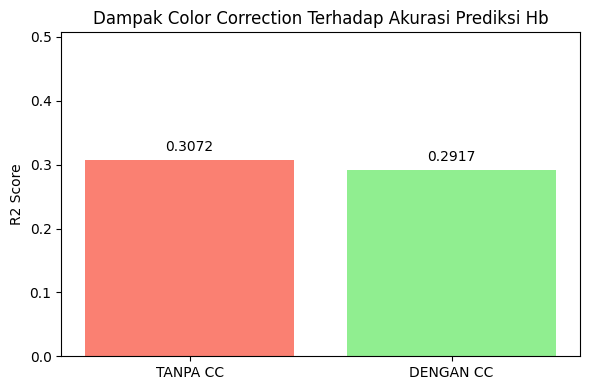

In [8]:
features_raw_list = []
features_cc_list = []
y_true = []

# 2. PROSES EKSTRAKSI
for idx, data in enumerate(data_validasi):
    print(f"Memproses Sampel {idx+1}/{len(data_validasi)}...")
    
    # a. Load Data
    img_ori = ambil_gambar_raw(data['dng_path'])
    cc_ori = ambil_gambar_raw(data['cc_path'])
    
    mask_ori = cv2.imread(data['mask_path'], cv2.IMREAD_GRAYSCALE)
    _, mask_ori = cv2.threshold(mask_ori, 127, 255, cv2.THRESH_BINARY)
    if mask_ori.shape != img_ori.shape[:2]:
        mask_ori = cv2.resize(mask_ori, (img_ori.shape[1], img_ori.shape[0]), interpolation=cv2.INTER_NEAREST)

    # b. Pipeline Preprocessing
    roi_img, roi_mask = roi_cropping(img_ori, mask_ori)
    restored_img, _ = restoration(roi_img, roi_mask)
    corrected_img = color_correction(restored_img, cc_ori)
    
    # c. Ekstraksi 14 Fitur (Mengirim parameter gender dari dictionary)
    feat_raw = extract_14_rf_features(restored_img, roi_mask, data['gender_encoded'])
    feat_cc  = extract_14_rf_features(corrected_img, roi_mask, data['gender_encoded'])
    
    features_raw_list.append(feat_raw)
    features_cc_list.append(feat_cc)
    y_true.append(data['hb_true'])

# Ubah ke DataFrame
X_raw_df = pd.DataFrame(features_raw_list)
X_cc_df = pd.DataFrame(features_cc_list)

# MENGUNCI URUTAN KOLOM SESUAI MODEL TRAINING
urutan_fitur = [
    'A_Mean', 'H_Skew', 'H_Std', 'B_lab_Std', 'Erythema_Index', 
    'High_Hue_Ratio', 'S_Mean', 'A_Std', 'B_lab_Mean', 'S_Std', 
    'R_Mean', 'Gender_Encoded', 'B_Mean', 'Red_Ratio'
]
X_raw_df = X_raw_df[urutan_fitur]
X_cc_df = X_cc_df[urutan_fitur]

# 3. EVALUASI DENGAN MODEL RF TERBAIK
PATH_MODEL_RF = r'C:\Folder Dzakwan\Folder Dzakwan\Keperluan TA\models\weights\saved_models\Random_Forest_RF_best.joblib'

try:
    best_rf_model = joblib.load(PATH_MODEL_RF)
    print("\nModel RF berhasil dimuat!")
    
    y_pred_raw = best_rf_model.predict(X_raw_df)
    y_pred_cc = best_rf_model.predict(X_cc_df)
    
    r2_raw = r2_score(y_true, y_pred_raw)
    r2_cc = r2_score(y_true, y_pred_cc)
    
    print("\n=== HASIL ABLATION VALIDATION ===")
    print(f"R2 Score (TANPA CC)  : {r2_raw:.4f}")
    print(f"R2 Score (DENGAN CC) : {r2_cc:.4f}")
    
    labels = ['TANPA CC', 'DENGAN CC']
    r2_scores = [r2_raw, r2_cc]

    plt.figure(figsize=(6, 4))
    bars = plt.bar(labels, r2_scores, color=['salmon', 'lightgreen'])
    for bar in bars:
        yval = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, yval + 0.01, f'{yval:.4f}', ha='center', va='bottom')

    plt.title('Dampak Color Correction Terhadap Akurasi Prediksi Hb')
    plt.ylabel('R2 Score')
    plt.ylim(0, max(r2_scores) + 0.2)
    plt.tight_layout()
    plt.show()

except FileNotFoundError:
    print(f"\nError: Model tidak ditemukan di path: {PATH_MODEL_RF}")

In [31]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np


Model RF berhasil dimuat!

=== HASIL ABLATION VALIDATION ===
Metrik     | TANPA CC   | DENGAN CC 
-------------------------------------
R2 Score   | 0.3072     | 0.2917    
RMSE       | 1.7525     | 1.7719    
MAE        | 1.4120     | 1.4306    


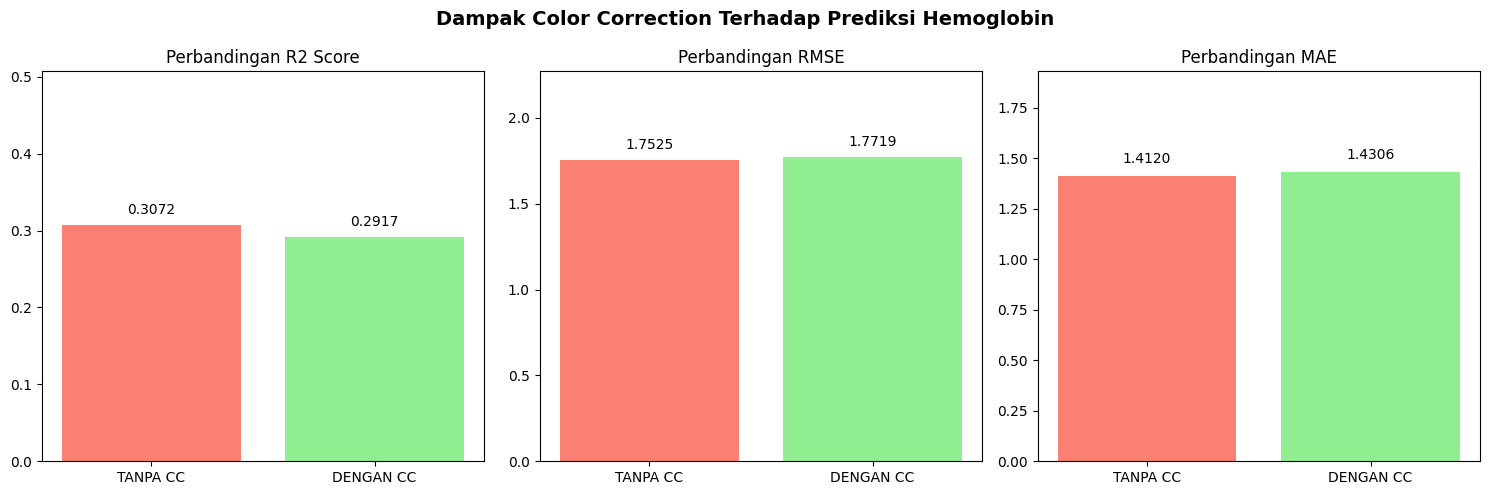

In [32]:
# 3. EVALUASI DENGAN MODEL RF TERBAIK
PATH_MODEL_RF = r'C:\Folder Dzakwan\Folder Dzakwan\Keperluan TA\models\weights\saved_models\Random_Forest_RF_best.joblib'

try:
    best_rf_model = joblib.load(PATH_MODEL_RF)
    print("\nModel RF berhasil dimuat!")
    
    # Prediksi menggunakan fitur raw dan fitur dengan CC
    y_pred_raw = best_rf_model.predict(X_raw_df)
    y_pred_cc = best_rf_model.predict(X_cc_df)
    
    # Menghitung R2 Score
    r2_raw = r2_score(y_true, y_pred_raw)
    r2_cc = r2_score(y_true, y_pred_cc)
    
    # Menghitung RMSE (Root Mean Squared Error)
    rmse_raw = np.sqrt(mean_squared_error(y_true, y_pred_raw))
    rmse_cc = np.sqrt(mean_squared_error(y_true, y_pred_cc))
    
    # Menghitung MAE (Mean Absolute Error)
    mae_raw = mean_absolute_error(y_true, y_pred_raw)
    mae_cc = mean_absolute_error(y_true, y_pred_cc)
    
    # Menampilkan hasil teks
    print("\n=== HASIL ABLATION VALIDATION ===")
    print(f"{'Metrik':<10} | {'TANPA CC':<10} | {'DENGAN CC':<10}")
    print("-" * 37)
    print(f"{'R2 Score':<10} | {r2_raw:<10.4f} | {r2_cc:<10.4f}")
    print(f"{'RMSE':<10} | {rmse_raw:<10.4f} | {rmse_cc:<10.4f}")
    print(f"{'MAE':<10} | {mae_raw:<10.4f} | {mae_cc:<10.4f}")
    
    # Visualisasi R2, RMSE, dan MAE dalam 3 Subplot
    labels = ['TANPA CC', 'DENGAN CC']
    warna = ['salmon', 'lightgreen']
    
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    # 1. Plot R2 Score (Semakin tinggi semakin baik)
    bars_r2 = axes[0].bar(labels, [r2_raw, r2_cc], color=warna)
    axes[0].set_title('Perbandingan R2 Score')
    axes[0].set_ylim(0, max(r2_raw, r2_cc) + 0.2)
    for bar in bars_r2:
        yval = bar.get_height()
        axes[0].text(bar.get_x() + bar.get_width()/2, yval + 0.01, f'{yval:.4f}', ha='center', va='bottom')
        
    # 2. Plot RMSE (Semakin rendah semakin baik)
    bars_rmse = axes[1].bar(labels, [rmse_raw, rmse_cc], color=warna)
    axes[1].set_title('Perbandingan RMSE')
    axes[1].set_ylim(0, max(rmse_raw, rmse_cc) + 0.5)
    for bar in bars_rmse:
        yval = bar.get_height()
        axes[1].text(bar.get_x() + bar.get_width()/2, yval + 0.05, f'{yval:.4f}', ha='center', va='bottom')
        
    # 3. Plot MAE (Semakin rendah semakin baik)
    bars_mae = axes[2].bar(labels, [mae_raw, mae_cc], color=warna)
    axes[2].set_title('Perbandingan MAE')
    axes[2].set_ylim(0, max(mae_raw, mae_cc) + 0.5)
    for bar in bars_mae:
        yval = bar.get_height()
        axes[2].text(bar.get_x() + bar.get_width()/2, yval + 0.05, f'{yval:.4f}', ha='center', va='bottom')
        
    plt.suptitle('Dampak Color Correction Terhadap Prediksi Hemoglobin', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

except FileNotFoundError:
    print(f"\nError: Model tidak ditemukan di path: {PATH_MODEL_RF}")
except Exception as e:
    print(f"\nTerjadi kesalahan saat evaluasi: {e}")

In [33]:
import matplotlib.pyplot as plt
import cv2
import numpy as np
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import pandas as pd
import joblib

# Fungsi untuk memvisualisasikan perbandingan sebelum dan sesudah denoising
def visualisasi_efek_brightspot(img_sebelum, img_sesudah, mask):
    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    
    # Plot Gambar
    axes[0, 0].imshow(img_sebelum)
    axes[0, 0].set_title('Sebelum Denoising (ROI Asli)')
    axes[0, 0].axis('off')
    
    axes[0, 1].imshow(img_sesudah)
    axes[0, 1].set_title('Sesudah Denoising (Restored)')
    axes[0, 1].axis('off')
    
    # Plot Histogram (Fokus pada area konjungtiva saja)
    colors = ('r', 'g', 'b')
    for i, color in enumerate(colors):
        hist_seb = cv2.calcHist([img_sebelum], [i], mask, [256], [0, 256])
        axes[1, 0].plot(hist_seb, color=color)
        axes[1, 0].set_xlim([0, 256])
        
        hist_ses = cv2.calcHist([img_sesudah], [i], mask, [256], [0, 256])
        axes[1, 1].plot(hist_ses, color=color)
        axes[1, 1].set_xlim([0, 256])

    axes[1, 0].set_title('Histogram Sebelum (Perhatikan Spike di Kanan)')
    axes[1, 1].set_title('Histogram Sesudah Denoising')
    plt.tight_layout()
    plt.show()

# Fungsi untuk menghitung persentase piksel saturasi (overexposed)
def persentase_brightspot(img, mask, threshold=240):
    piksel_valid = img[mask == 255]
    if piksel_valid.size == 0:
        return 0
    overexposed = np.sum(piksel_valid > threshold)
    total_piksel = piksel_valid.size
    return (overexposed / total_piksel) * 100

=== MEMULAI EKSTRAKSI FITUR UNTUK EVALUASI DENOISING ===
Memproses Sampel 1/106...

Menampilkan contoh efek Brightspot Denoising (Sampel 1):


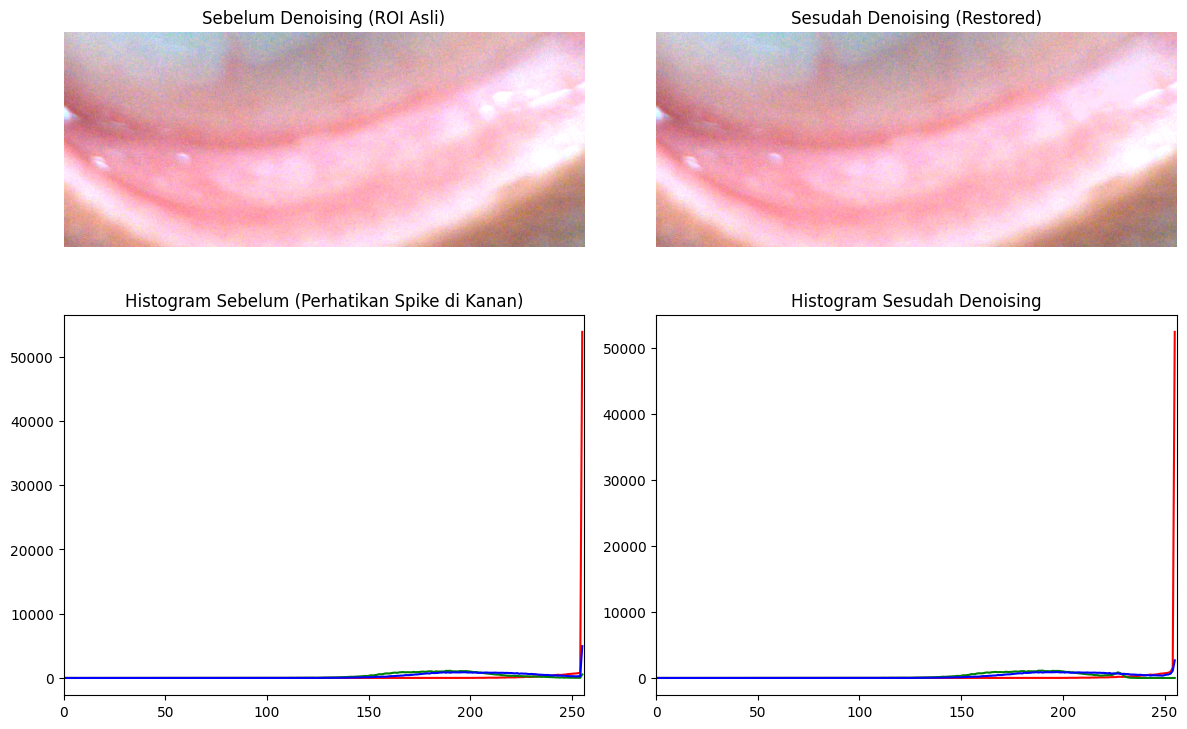

Initial mean DeltaE:  10.5953270699
Number of components:  10
Initial mean DeltaE:  10.5953270699
Number of components:  10
Memproses Sampel 2/106...
Initial mean DeltaE:  4.41065700725
Number of components:  10
Initial mean DeltaE:  4.41065700725
Number of components:  10
Memproses Sampel 3/106...
Initial mean DeltaE:  7.80193105263
Number of components:  10
Initial mean DeltaE:  7.80193105263
Number of components:  10
Memproses Sampel 4/106...
Initial mean DeltaE:  7.80193105263
Number of components:  10
Initial mean DeltaE:  7.80193105263
Number of components:  10
Memproses Sampel 5/106...
Initial mean DeltaE:  6.87623276149
Number of components:  10
Initial mean DeltaE:  6.87623276149
Number of components:  10
Memproses Sampel 6/106...
Initial mean DeltaE:  6.87623276149
Number of components:  10
Initial mean DeltaE:  6.87623276149
Number of components:  10
Memproses Sampel 7/106...
Initial mean DeltaE:  8.20507121924
Number of components:  10
Initial mean DeltaE:  8.20507121924
Nu

In [35]:
import cv2
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

features_no_denoise_list = []
features_with_denoise_list = []
y_true = []

# Variabel untuk menyimpan rata-rata saturasi
total_sat_sebelum = 0
total_sat_sesudah = 0

# BARU: Variabel untuk menyimpan rata-rata standar deviasi
total_std_sebelum = 0
total_std_sesudah = 0

print("=== MEMULAI EKSTRAKSI FITUR UNTUK EVALUASI DENOISING ===")
for idx, data in enumerate(data_validasi):
    print(f"Memproses Sampel {idx+1}/{len(data_validasi)}...")
    
    # a. Load Data
    img_ori = ambil_gambar_raw(data['dng_path'])
    cc_ori = ambil_gambar_raw(data['cc_path'])
    
    mask_ori = cv2.imread(data['mask_path'], cv2.IMREAD_GRAYSCALE)
    _, mask_ori = cv2.threshold(mask_ori, 127, 255, cv2.THRESH_BINARY)
    if mask_ori.shape != img_ori.shape[:2]:
        mask_ori = cv2.resize(mask_ori, (img_ori.shape[1], img_ori.shape[0]), interpolation=cv2.INTER_NEAREST)

    # b. Pipeline Preprocessing
    roi_img, roi_mask = roi_cropping(img_ori, mask_ori)
    restored_img, _ = restoration(roi_img, roi_mask)
    
    # [Opsional] Memanggil visualisasi untuk sampel pertama saja sebagai bukti di naskah
    if idx == 0:
        print("\nMenampilkan contoh efek Brightspot Denoising (Sampel 1):")
        visualisasi_efek_brightspot(roi_img, restored_img, roi_mask)
        
    # Hitung dan akumulasi persentase piksel saturasi
    total_sat_sebelum += persentase_brightspot(roi_img, roi_mask)
    total_sat_sesudah += persentase_brightspot(restored_img, roi_mask)
    
    # BARU: Hitung dan akumulasi Standar Deviasi (menggunakan cv2.meanStdDev dengan mask)
    # Output cv2.meanStdDev adalah tuple (mean, stddev) untuk masing-masing channel (R, G, B)
    _, std_seb = cv2.meanStdDev(roi_img, mask=roi_mask)
    _, std_ses = cv2.meanStdDev(restored_img, mask=roi_mask)
    
    # Kita ambil rata-rata standar deviasi dari ketiga channel warna tersebut
    total_std_sebelum += np.mean(std_seb)
    total_std_sesudah += np.mean(std_ses)
    
    # c. Terapkan Color Correction pada kedua versi
    cc_no_denoise = color_correction(roi_img, cc_ori) 
    cc_with_denoise = color_correction(restored_img, cc_ori)
    
    # d. Ekstraksi 14 Fitur
    feat_no_denoise = extract_14_rf_features(cc_no_denoise, roi_mask, data['gender_encoded'])
    feat_with_denoise = extract_14_rf_features(cc_with_denoise, roi_mask, data['gender_encoded'])
    
    features_no_denoise_list.append(feat_no_denoise)
    features_with_denoise_list.append(feat_with_denoise)
    y_true.append(data['hb_true'])

# BARU: Menampilkan rata-rata penurunan piksel overexposed dan perubahan homogenitas
print("\n=== ANALISIS CITRA: TINGKAT SATURASI & HOMOGENITAS ===")
print(f"Rata-rata area saturasi sebelum denoising   : {total_sat_sebelum / len(data_validasi):.2f}%")
print(f"Rata-rata area saturasi sesudah denoising   : {total_sat_sesudah / len(data_validasi):.2f}%")

# Ubah ke DataFrame
X_no_denoise_df = pd.DataFrame(features_no_denoise_list)
X_with_denoise_df = pd.DataFrame(features_with_denoise_list)

# MENGUNCI URUTAN KOLOM SESUAI MODEL TRAINING
urutan_fitur = [
    'A_Mean', 'H_Skew', 'H_Std', 'B_lab_Std', 'Erythema_Index', 
    'High_Hue_Ratio', 'S_Mean', 'A_Std', 'B_lab_Mean', 'S_Std', 
    'R_Mean', 'Gender_Encoded', 'B_Mean', 'Red_Ratio'
]
X_no_denoise_df = X_no_denoise_df[urutan_fitur]
X_with_denoise_df = X_with_denoise_df[urutan_fitur]


Model RF berhasil dimuat!

=== HASIL ABLATION VALIDATION (DENOISING) ===
Metrik     | TANPA DENOISE   | DENGAN DENOISE 
-----------------------------------------------
R2 Score   | 0.2921          | 0.2917         
RMSE       | 1.7713          | 1.7719         
MAE        | 1.4304          | 1.4306         


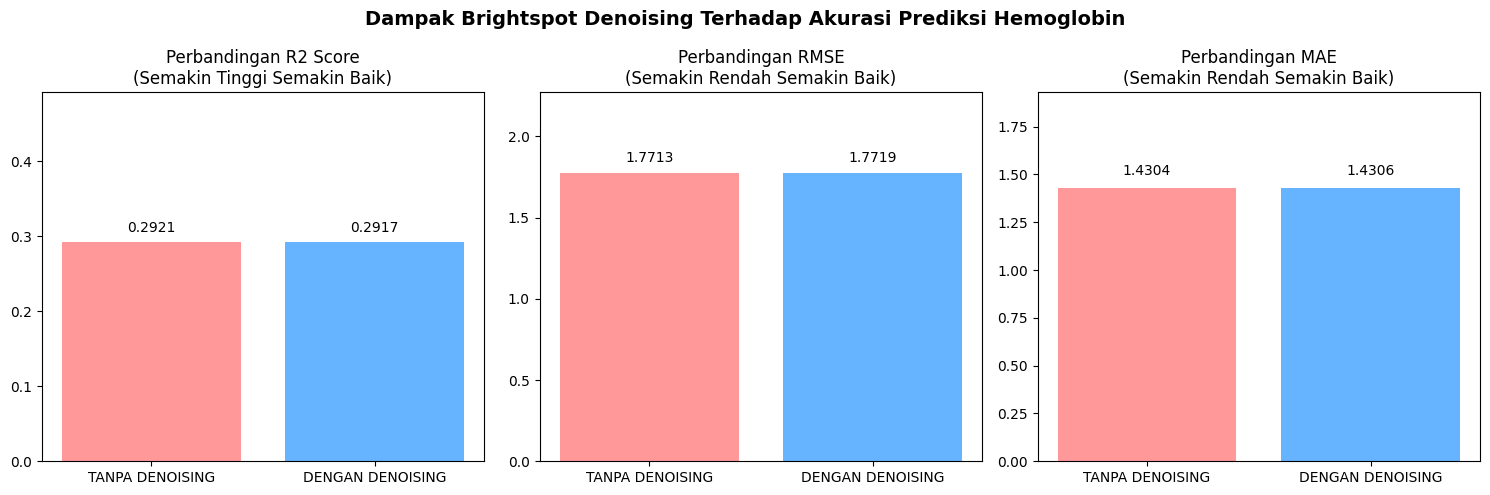

In [22]:
# 3. EVALUASI DENGAN MODEL RF TERBAIK
PATH_MODEL_RF = r'C:\Folder Dzakwan\Folder Dzakwan\Keperluan TA\models\weights\saved_models\Random_Forest_RF_best.joblib'

try:
    best_rf_model = joblib.load(PATH_MODEL_RF)
    print("\nModel RF berhasil dimuat!")
    
    # Prediksi menggunakan fitur tanpa denoising dan dengan denoising
    y_pred_no_denoise = best_rf_model.predict(X_no_denoise_df)
    y_pred_with_denoise = best_rf_model.predict(X_with_denoise_df)
    
    # Menghitung R2 Score
    r2_no = r2_score(y_true, y_pred_no_denoise)
    r2_with = r2_score(y_true, y_pred_with_denoise)
    
    # Menghitung RMSE
    rmse_no = np.sqrt(mean_squared_error(y_true, y_pred_no_denoise))
    rmse_with = np.sqrt(mean_squared_error(y_true, y_pred_with_denoise))
    
    # Menghitung MAE
    mae_no = mean_absolute_error(y_true, y_pred_no_denoise)
    mae_with = mean_absolute_error(y_true, y_pred_with_denoise)
    
    # Menampilkan hasil teks berupa tabel
    print("\n=== HASIL ABLATION VALIDATION (DENOISING) ===")
    print(f"{'Metrik':<10} | {'TANPA DENOISE':<15} | {'DENGAN DENOISE':<15}")
    print("-" * 47)
    print(f"{'R2 Score':<10} | {r2_no:<15.4f} | {r2_with:<15.4f}")
    print(f"{'RMSE':<10} | {rmse_no:<15.4f} | {rmse_with:<15.4f}")
    print(f"{'MAE':<10} | {mae_no:<15.4f} | {mae_with:<15.4f}")
    
    # Visualisasi R2, RMSE, dan MAE dalam 3 Subplot
    labels = ['TANPA DENOISING', 'DENGAN DENOISING']
    warna = ['#ff9999', '#66b3ff']
    
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    # 1. Plot R2 Score 
    bars_r2 = axes[0].bar(labels, [r2_no, r2_with], color=warna)
    axes[0].set_title('Perbandingan R2 Score\n(Semakin Tinggi Semakin Baik)')
    axes[0].set_ylim(0, max(r2_no, r2_with) + 0.2)
    for bar in bars_r2:
        yval = bar.get_height()
        axes[0].text(bar.get_x() + bar.get_width()/2, yval + 0.01, f'{yval:.4f}', ha='center', va='bottom')
        
    # 2. Plot RMSE 
    bars_rmse = axes[1].bar(labels, [rmse_no, rmse_with], color=warna)
    axes[1].set_title('Perbandingan RMSE\n(Semakin Rendah Semakin Baik)')
    axes[1].set_ylim(0, max(rmse_no, rmse_with) + 0.5)
    for bar in bars_rmse:
        yval = bar.get_height()
        axes[1].text(bar.get_x() + bar.get_width()/2, yval + 0.05, f'{yval:.4f}', ha='center', va='bottom')
        
    # 3. Plot MAE 
    bars_mae = axes[2].bar(labels, [mae_no, mae_with], color=warna)
    axes[2].set_title('Perbandingan MAE\n(Semakin Rendah Semakin Baik)')
    axes[2].set_ylim(0, max(mae_no, mae_with) + 0.5)
    for bar in bars_mae:
        yval = bar.get_height()
        axes[2].text(bar.get_x() + bar.get_width()/2, yval + 0.05, f'{yval:.4f}', ha='center', va='bottom')
        
    plt.suptitle('Dampak Brightspot Denoising Terhadap Akurasi Prediksi Hemoglobin', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

except FileNotFoundError:
    print(f"\nError: Model tidak ditemukan di path: {PATH_MODEL_RF}")
except Exception as e:
    print(f"\nTerjadi kesalahan saat evaluasi: {e}")